In [12]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [15]:
# basic supervised dataset
def load_data(tweet1, emoji1):
    tweets = []
    with open(tweet1, "r", encoding="utf-8") as f:
        for line in f:
            tweets.append(line.strip())
    emojis = []
    with open(emoji1, "r", encoding="utf-8") as f:
        for line in f:
            emojis.append(line.strip())
    return tweets, emojis    
tweets, emojis = load_data("tweets.txt", "emoji.txt")
print("Total samples:", len(tweets))

Total samples: 225331


In [7]:
#inspection
for i in random.sample(range(len(tweets)), 10):
    print(tweets[i], "=", emojis[i])

Omg I'm so starving right now, I could literally demolish a dominos pizza = heart_eyes
Why is this @McDonalds drive thru line so long = weary
@morganndeal miss you too come back to Starbucks = sob
RT @TillerDaily: When Tiller goes to Subway  https://t.co/tvyW890KdT = sob
RT @eeesparza123: Applied at Starbucks. I hope I get it = grin
@love_ur_people @TheTeamSawyer @SawyerFrdrx yep...that's what Sawyer's singing would do to you. I bet this is how I looked like too = blush
Some of the items on Sheetz menu are just disturbing = weary
Got my Starbucks = yum
@maeeemarieee  are they good ? I seen dem at walmart  i lw wanted to get them = sob
RT @Koreaboo: Happy Birthday subway signs are so cute  Here's one fans put up for Nayeon's birthday! Have you seen others? #HappyNayeonDa… = heart_eyes


In [ ]:
#observations: slang, RT, mentions, informal tone

In [16]:
# removing metadata, RT@user, URLs, @mentions, #( keep the word but remove symbol ), HTML &amp;): decode
#extracting signals and removing stuff that does not help predict emoji
#keep semantic content and remove structural noise
import re
import html
def processed_text(text):
    text = html.unescape(text)
    text = re.sub(r'\bRT\s+@\w+:', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
tweets_processed = [processed_text(i) for i in tweets]

In [20]:
#checking after cleaning dataset
for i in range(5):
    print("original:", tweets[i])
    print("processed:", tweets_processed[i])
    print("-"*50)

original: RT @VibingOverHoes: Bet you'll get hungry  https://t.co/hOOU9xpmVq
processed: Bet you'll get hungry
--------------------------------------------------
original: Starbucks employee confuses boyfriend by saying is penis is tall
processed: Starbucks employee confuses boyfriend by saying is penis is tall
--------------------------------------------------
original: When your Starbucks store makes you an iced mocha instead of white mocha
processed: When your Starbucks store makes you an iced mocha instead of white mocha
--------------------------------------------------
original: Being told "girl your romper looks fierce!" At the subway today made me so happy, it is the little things that make all the difference
processed: Being told "girl your romper looks fierce!" At the subway today made me so happy, it is the little things that make all the difference
--------------------------------------------------
original: I got a Starbucks drink at school today, shit tasted soooo nasty I 

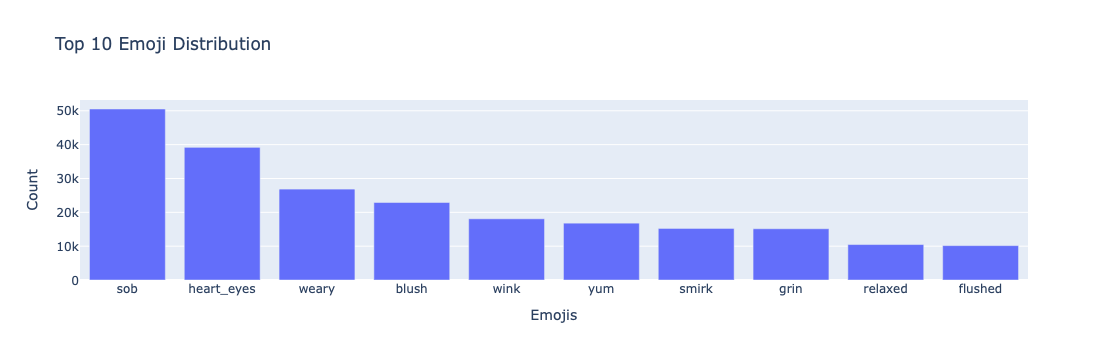

In [24]:
from collections import Counter
import plotly.graph_objects as go
import plotly.io as pio
emoji_count1 = Counter(emojis)
top_emojis = emoji_count1.most_common(10)
labels = []
counts = []
for item in top_emojis:
    labels.append(item[0])
    counts.append(item[1])
fig = go.Figure(data=[
    go.Bar(x=labels, y=counts)
])
fig.update_layout(
    title="Top 10 Emoji Distribution",
    xaxis_title="Emojis",
    yaxis_title="Count"
)
fig.show()

dataset is imbalanced, example sob: 50k and flushed: 10k
model will bias towards common emojis
rare emojis harder to predict

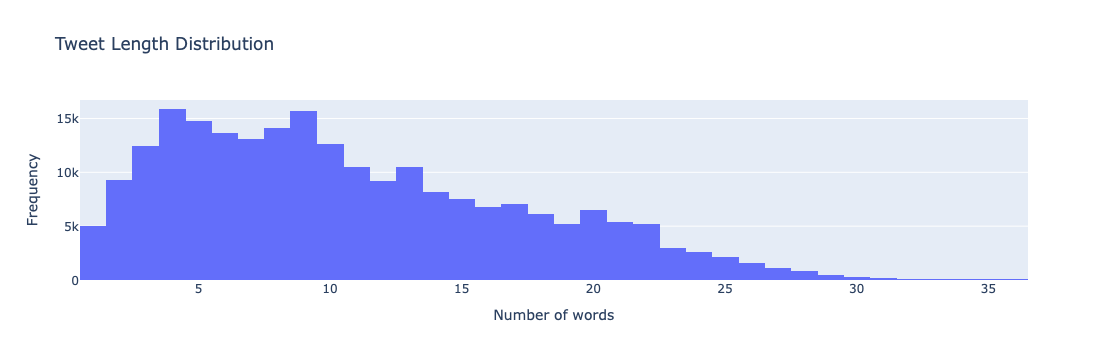

In [25]:
# measuring number of words per tweet
lengths = []
for i in tweets_processed:
    lengths.append(len(i.split()))
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Histogram(x=lengths, nbinsx=50)]
)
fig.update_layout(
    title="Tweet Length Distribution",
    xaxis_title="Number of words",
    yaxis_title="Frequency"
)
fig.show()

observations: tweets are short
less text-> less context-> more ambiguity (preliminary thinking)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=20)
def top_words_for_emoji(target):
    subset = [tweets_processed[i] for i in range(len(tweets_processed)) if emojis[i] == target]
    if len(subset) < 10:
        return
    X = vectorizer.fit_transform(subset)
    words = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    print(f"\nTop words for {target}:")
    for w, c in sorted(zip(words, counts), key=lambda x: -x[1])[:10]:
        print(w, c)
top_words_for_emoji("heart_eyes")
top_words_for_emoji("sob")


Top words for heart_eyes:
starbucks 12544
bet 12344
you 9179
the 7592
to 6920
and 5718
my 4939
is 4637
it 4372
for 4311

Top words for sob:
bet 17940
starbucks 12369
to 11712
the 10842
my 9045
and 8989
me 8733
you 7688
this 7264
so 6295


Same words (e.g., starbucks, bet, you) appear across different emojis like heart_eyes and sob.
This shows that text alone does not uniquely determine emojis, making prediction inherently ambiguous and context-dependent.

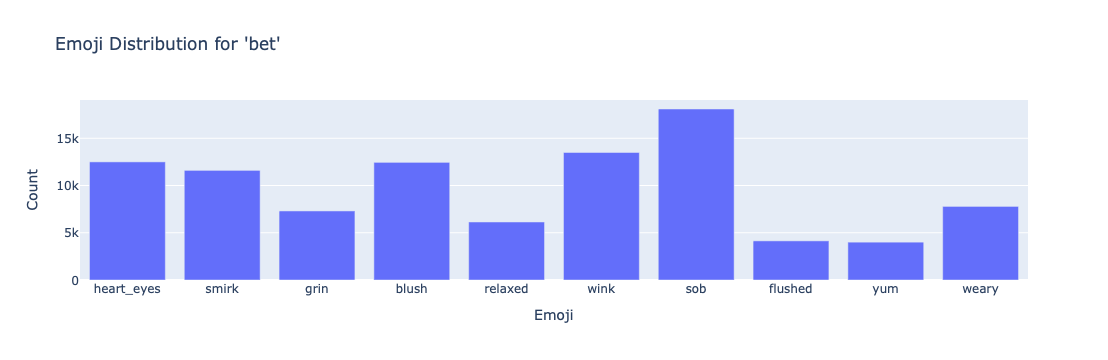

In [53]:
import plotly.graph_objects as go
from collections import Counter
bet_emojis = [e for t, e in zip(tweets_processed, emojis) if "bet" in t.lower()]
bet_counts = Counter(bet_emojis)
labels = list(bet_counts.keys())
values = list(bet_counts.values())
fig = go.Figure()

fig.add_trace(go.Bar(
    x=labels,
    y=values
))
fig.update_layout(
    title="Emoji Distribution for 'bet'",
    xaxis_title="Emoji",
    yaxis_title="Count"
)
fig.show()

In [56]:
def show_examples(target, n=10):
    examples = [tweets_processed[i] for i in range(len(tweets_processed)) if emojis[i] == target]
    for t in random.sample(examples, min(n, len(examples))):
        print(t)
        print("-"*40)
show_examples("heart_eyes")
show_examples("flushed")

I love McDonalds iced coffee
----------------------------------------
I bet
----------------------------------------
MORE THAN JUST PETCAHHHH!!!
----------------------------------------
MCDONALDS HI C IS SO GOOD
----------------------------------------
I want Starbucks omfg
----------------------------------------
I bet it's so pretty...
----------------------------------------
starbucks beauty @ New Westminster, British Columbia
----------------------------------------
I bet it is
----------------------------------------
I need a Volkswagen
----------------------------------------
during this Election Year I miss JoanRivers so much- she would have loved tweeting on daily water cooler topics bet she would go Trump
----------------------------------------
What are they putting in Starbucks these days
----------------------------------------
By watching that id say kell brooks corner had a sneaky bet on for the 5th
----------------------------------------
I have escalated to SIX shots (@

- Same phrase (“bet”) maps to multiple emojis → not one-to-one
- Some emojis (heart_eyes) show consistent usage, others (flushed) are highly variable
- Emoji prediction varies: some are predictable, others inherently ambiguous

- Emoji prediction is affected by imbalance, short context, overlapping vocabulary, and inherent ambiguity
- The task is fundamentally ambiguous and context-dependent, not limited by preprocessing or models
- Next: use embeddings to show multiple meanings per emoji and overlapping semantic clusters

In [21]:
#now moving to semantic analysis

In [57]:
!pip install sentence-transformers umap-learn
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import numpy as np


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [58]:
model = SentenceTransformer('all-mpnet-base-v2')

Loading weights: 100%|█████████████████████| 199/199 [00:00<00:00, 18410.68it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [59]:
selected_emojis = ["sob", "heart_eyes", "flushed", "wink", "grin", "weary"]
filtered_tweets = []
filtered_labels = []
for t, e in zip(tweets_processed, emojis):
    if e in selected_emojis:
        filtered_tweets.append(t)
        filtered_labels.append(e)
filtered_tweets = filtered_tweets[:10000]
filtered_labels = filtered_labels[:10000]

In [60]:
embeddings = model.encode(filtered_tweets, show_progress_bar=True)

Batches: 100%|████████████████████████████████| 313/313 [00:22<00:00, 13.81it/s]


In [61]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
reduced = reducer.fit_transform(embeddings)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


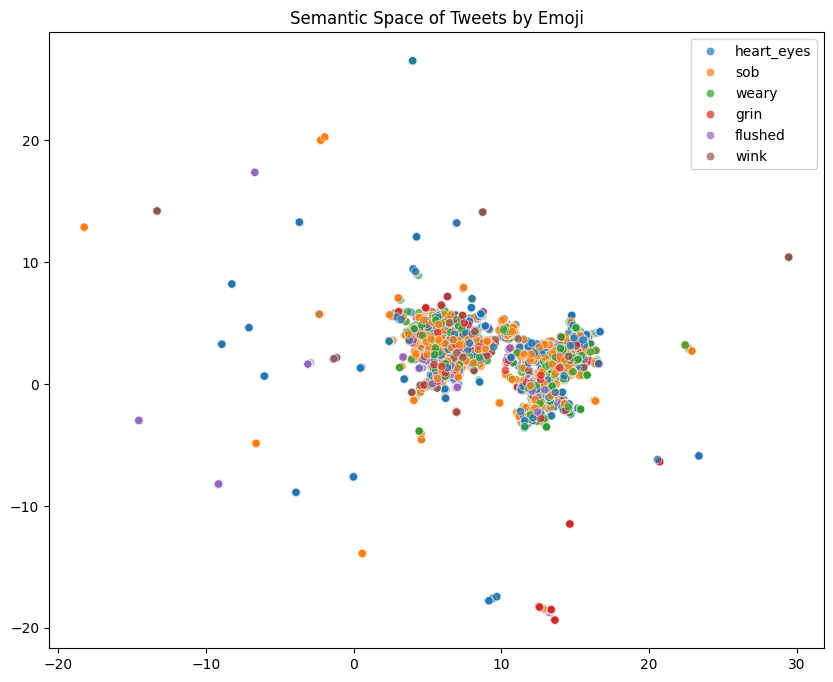

In [62]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=reduced[:,0],
    y=reduced[:,1],
    hue=filtered_labels,
    palette="tab10",
    alpha=0.7
)
plt.title("Semantic Space of Tweets by Emoji")
plt.legend()
plt.show()

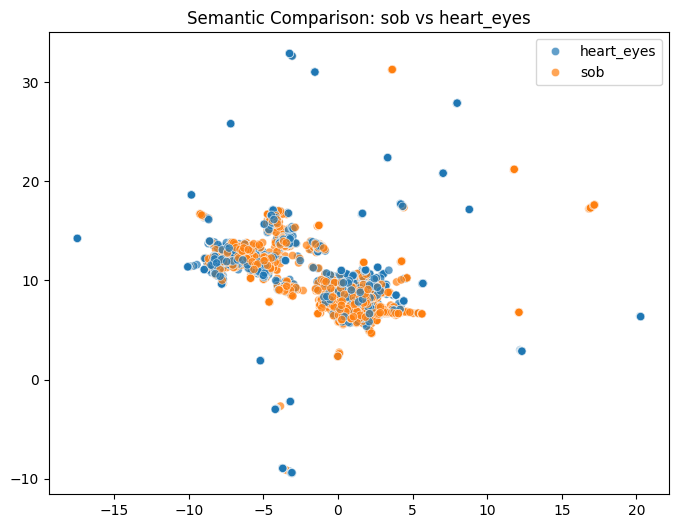

In [63]:
target_emojis = ["sob", "heart_eyes"]
subset_tweets = []
subset_labels = []
for t, e in zip(filtered_tweets, filtered_labels):
    if e in target_emojis:
        subset_tweets.append(t)
        subset_labels.append(e)
subset_emb = model.encode(subset_tweets)
subset_reduced = reducer.fit_transform(subset_emb)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=subset_reduced[:,0],
    y=subset_reduced[:,1],
    hue=subset_labels,
    alpha=0.7
)
plt.title("Semantic Comparison: sob vs heart_eyes")
plt.show()

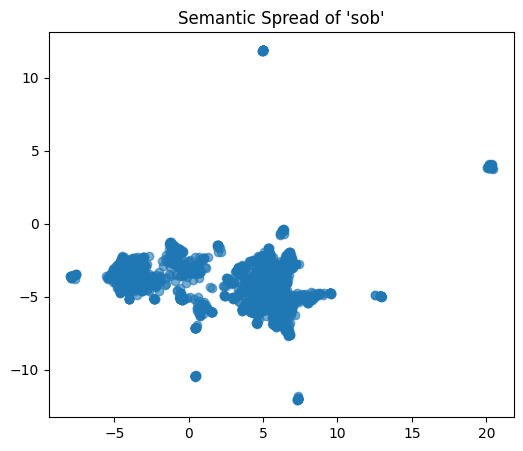

In [64]:
target = "sob"
subset = [t for t, e in zip(filtered_tweets, filtered_labels) if e == target]
subset_emb = model.encode(subset[:2000])
subset_reduced = reducer.fit_transform(subset_emb)
plt.figure(figsize=(6,5))
plt.scatter(subset_reduced[:,0], subset_reduced[:,1], alpha=0.6)
plt.title("Semantic Spread of 'sob'")
plt.show()

- Different emojis overlap → not separable
- Same emoji forms multiple clusters → multi-meaning
- Some emojis tight (consistent), others scattered (ambiguous)

Semantic embeddings reveal that emoji classes are not linearly separable, with overlapping regions across emojis and multiple distinct clusters within the same emoji, indicating strong contextual dependence and ambiguity.

Semantic representations of tweets show significant overlap across emoji labels, indicating that similar textual contexts correspond to multiple emojis.

In [30]:
len(set(emojis))

10

In [31]:
unique_emojis = list(set(emojis))
print(unique_emojis)

['heart_eyes', 'wink', 'smirk', 'grin', 'sob', 'weary', 'yum', 'flushed', 'relaxed', 'blush']


In [51]:
#Now experiments to prove the hypotheses from the eda

class imbalance effect

In [66]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(
    tweets_processed, emojis, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1, random_state=42
)

In [67]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train_enc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
from sklearn.metrics import accuracy_score, f1_score
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("F1 (macro):", f1_score(y_test_enc, y_pred, average='macro'))

Accuracy: 0.4620010207025096
F1 (macro): 0.43101730647614034


In [73]:
import numpy as np
from collections import defaultdict
correct = defaultdict(int)
total = defaultdict(int)
for true, pred in zip(y_test_enc, y_pred):
    total[true] += 1
    if true == pred:
        correct[true] += 1
class_acc = {}
for cls in total:
    class_acc[cls] = correct[cls] / total[cls]
class_acc_named = {
    le.inverse_transform([cls])[0]: acc
    for cls, acc in class_acc.items()
}
for k, v in class_acc_named.items():
    print(k, round(v, 3))

blush 0.318
wink 0.384
weary 0.34
sob 0.658
yum 0.397
heart_eyes 0.63
grin 0.3
smirk 0.324
flushed 0.427
relaxed 0.228


In [74]:
from collections import Counter
counts = Counter(y_train)
class_freq = dict(counts)

In [75]:
results = []
for emoji in class_acc_named:
    results.append({
        "emoji": emoji,
        "count": class_freq.get(emoji, 0),
        "accuracy": class_acc_named[emoji]
    })
results = sorted(results, key=lambda x: x["count"], reverse=True)

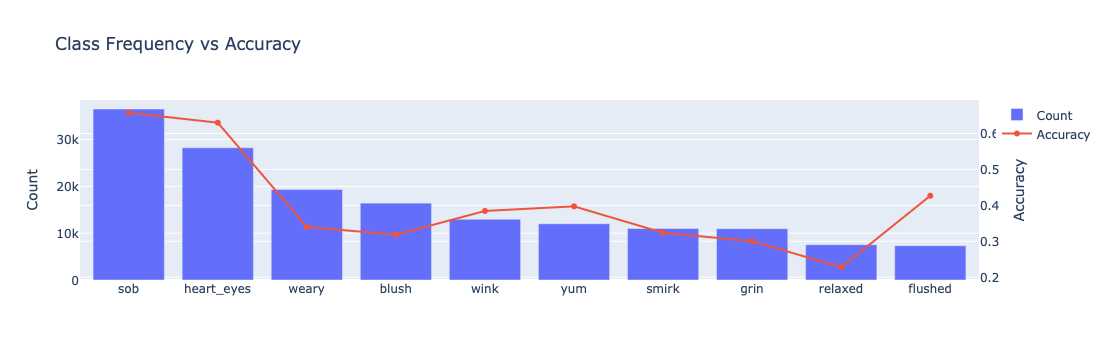

In [76]:
import plotly.graph_objects as go
emojis_plot = [r["emoji"] for r in results]
counts_plot = [r["count"] for r in results]
acc_plot    = [r["accuracy"] for r in results]
fig = go.Figure()
fig.add_trace(go.Bar(
    x=emojis_plot,
    y=counts_plot,
    name="Count"
))
fig.add_trace(go.Scatter(
    x=emojis_plot,
    y=acc_plot,
    name="Accuracy",
    mode="lines+markers",
    yaxis="y2"
))
fig.update_layout(
    title="Class Frequency vs Accuracy",
    yaxis=dict(title="Count"),
    yaxis2=dict(title="Accuracy", overlaying='y', side='right')
)
fig.show()

While class imbalance contributes to performance differences, it is not the dominant factor, as semantic ambiguity leads to varying accuracies even among similarly frequent emojis.

In [58]:
#text length vs accuracy

In [81]:
preds = model.predict(X_test_vec)

In [82]:
preds = le.inverse_transform(preds)

In [83]:
lengths = [len(t.split()) for t in X_test]
bins = [5, 10, 15, 20, 100]
bin_correct = [0]*len(bins)
bin_total = [0]*len(bins)
for i in range(len(X_test)):
    l = lengths[i]
    for j in range(len(bins)):
        if l <= bins[j]:
            bin_total[j] += 1
            
            if preds[i] == y_test[i]:
                bin_correct[j] += 1             
            break

In [84]:
bin_acc = []
for j in range(len(bins)):
    if bin_total[j] > 0:
        acc = bin_correct[j] / bin_total[j]
    else:
        acc = 0
    bin_acc.append(acc)

In [85]:
for j in range(len(bins)):
    print(f"<= {bins[j]} words: {round(bin_acc[j], 3)}")

<= 5 words: 0.479
<= 10 words: 0.459
<= 15 words: 0.428
<= 20 words: 0.488
<= 100 words: 0.461


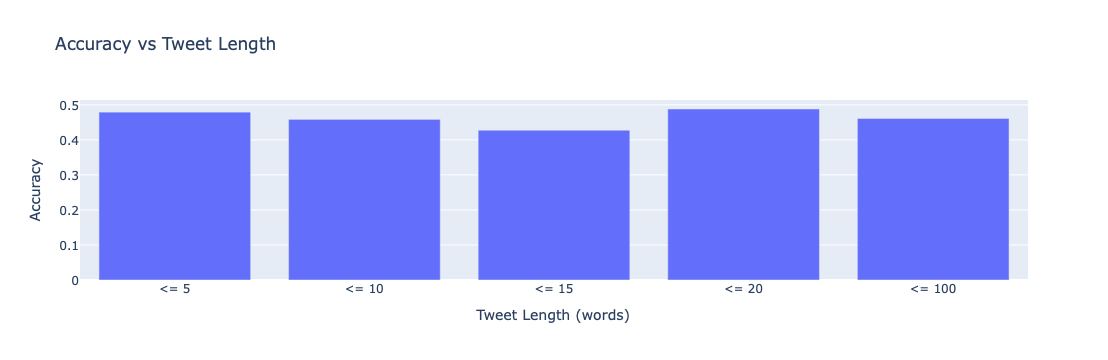

In [86]:
labels = [f"<= {b}" for b in bins]
fig = go.Figure()
fig.add_trace(go.Bar(
    x=labels,
    y=bin_acc
))
fig.update_layout(
    title="Accuracy vs Tweet Length",
    xaxis_title="Tweet Length (words)",
    yaxis_title="Accuracy"
)
fig.show()

- No clear trend: increasing text length does not consistently improve accuracy, showing more words is not equal to more clarity
- Emoji prediction is driven by semantic ambiguity (same text → multiple emojis, same emoji → multiple meanings), not just context or data factors
- Overall, the task is inherently ambiguous and context-dependent, disproving the assumption that more context alone improves prediction

- Most assumptions fail: metadata, text length, lexical mapping, and separability do not hold; only class imbalance partially helps
- Evidence shows strong semantic ambiguity: same text → multiple emojis, same emoji → multiple meanings, overlapping clusters
- Final insight: emoji prediction is inherently ambiguous and context-dependent, driven by semantic variability rather than data or model limitations

In [31]:
#train, test split with stratify for preserving class distribution
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    tweets_processed, emojis, test_size=0.3, random_state=42, stratify=emojis
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [32]:
# Training logistics regression ( baseline )

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
# Validation predictions
y_val_pred = lr.predict(X_val_vec)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
print("Validation Accuracy:", val_acc)
print("Validation F1:", val_f1)

Validation Accuracy: 0.4672189349112426
Validation F1: 0.44247575805288974


In [35]:
from sklearn.metrics import accuracy_score, f1_score
y_pred_lr = lr.predict(X_test_vec)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
print("Logistic Regression Accuracy:", acc_lr)
print("Logistic Regression F1:", f1_lr)

Logistic Regression Accuracy: 0.4666863905325444
Logistic Regression F1: 0.43672248933761876


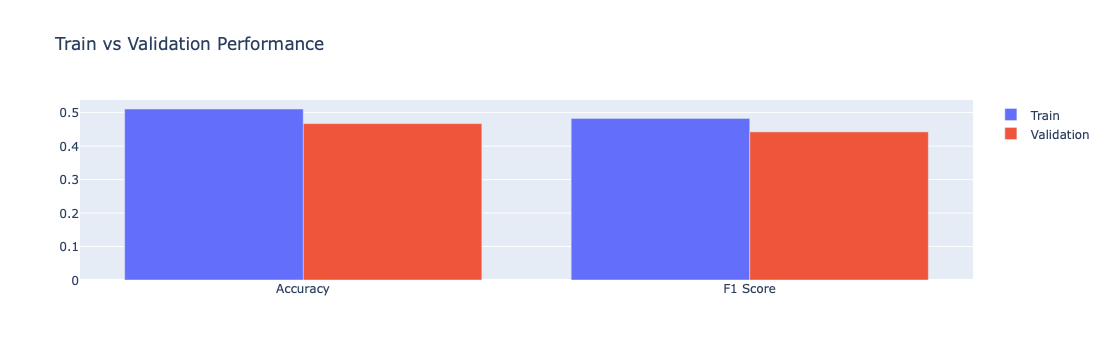

In [37]:
import plotly.graph_objects as go
metrics = ["Accuracy", "F1 Score"]
train_scores = [
    accuracy_score(y_train, lr.predict(X_train_vec)),
    f1_score(y_train, lr.predict(X_train_vec), average='macro')
]
val_scores = [val_acc, val_f1]
fig = go.Figure()
fig.add_trace(go.Bar(name="Train", x=metrics, y=train_scores))
fig.add_trace(go.Bar(name="Validation", x=metrics, y=val_scores))
fig.update_layout(
    title="Train vs Validation Performance",
    barmode='group'
)
fig.show()

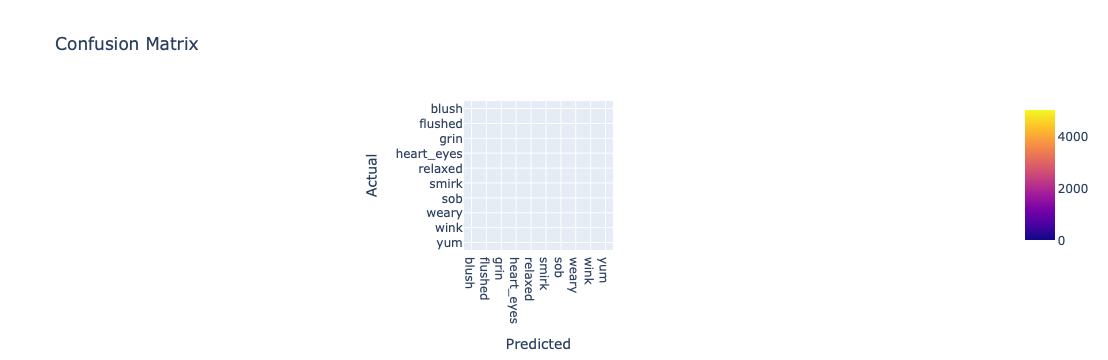

In [38]:
from sklearn.metrics import confusion_matrix
import plotly.express as px
cm = confusion_matrix(y_val, y_val_pred, labels=lr.classes_)
fig = px.imshow(cm,
                x=lr.classes_,
                y=lr.classes_,
                labels=dict(x="Predicted", y="Actual"),
                title="Confusion Matrix")
fig.show()

In [39]:
import numpy as np
probs = lr.predict_proba(X_val_vec)
top1 = 0
top3 = 0
for i in range(len(y_val)):
    true = y_val[i]
    top_indices = np.argsort(probs[i])[-3:]
    top_labels = [lr.classes_[j] for j in top_indices]
    if true == top_labels[-1]:
        top1 += 1
    if true in top_labels:
        top3 += 1
top1_acc = top1 / len(y_val)
top3_acc = top3 / len(y_val)
print("Top-1 Accuracy:", top1_acc)
print("Top-3 Accuracy:", top3_acc)

Top-1 Accuracy: 0.4672189349112426
Top-3 Accuracy: 0.7386094674556213


Logistic Regression provides a strong baseline, capturing surface-level lexical patterns, but fails to resolve semantic ambiguity inherent in emoji prediction.

In [40]:
#Now randome forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_vec, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
from sklearn.metrics import accuracy_score, f1_score
y_val_pred_rf = rf.predict(X_val_vec)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')
print("Random Forest Validation Accuracy:", val_acc_rf)
print("Random Forest Validation F1:", val_f1_rf)

Random Forest Validation Accuracy: 0.5367159763313609
Random Forest Validation F1: 0.5267443390768178


In [44]:
y_test_pred_rf = rf.predict(X_test_vec)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='macro')
print("Random Forest Test Accuracy:", test_acc_rf)
print("Random Forest Test F1:", test_f1_rf)

Random Forest Test Accuracy: 0.5414201183431953
Random Forest Test F1: 0.529616465295782


In [45]:
import numpy as np
probs_rf = rf.predict_proba(X_test_vec)
top1 = 0
top3 = 0
for i in range(len(y_test)):
    true = y_test[i]
    top_indices = np.argsort(probs_rf[i])[-3:]
    top_labels = [rf.classes_[j] for j in top_indices]
    if true == top_labels[-1]:
        top1 += 1
    if true in top_labels:
        top3 += 1
top1_acc_rf = top1 / len(y_test)
top3_acc_rf = top3 / len(y_test)
print("Random Forest Top-1 Accuracy:", top1_acc_rf)
print("Random Forest Top-3 Accuracy:", top3_acc_rf)

Random Forest Top-1 Accuracy: 0.5404733727810651
Random Forest Top-3 Accuracy: 0.7557100591715976


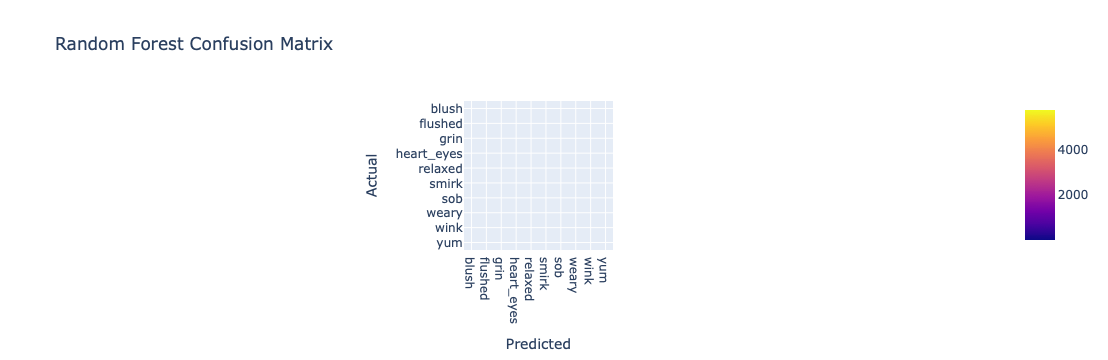

In [46]:
from sklearn.metrics import confusion_matrix
import plotly.express as px
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=rf.classes_)
fig = px.imshow(
    cm_rf,
    x=rf.classes_,
    y=rf.classes_,
    labels=dict(x="Predicted", y="Actual"),
    title="Random Forest Confusion Matrix"
)
fig.show()

In [47]:
#Comparing logistics regression and random forest

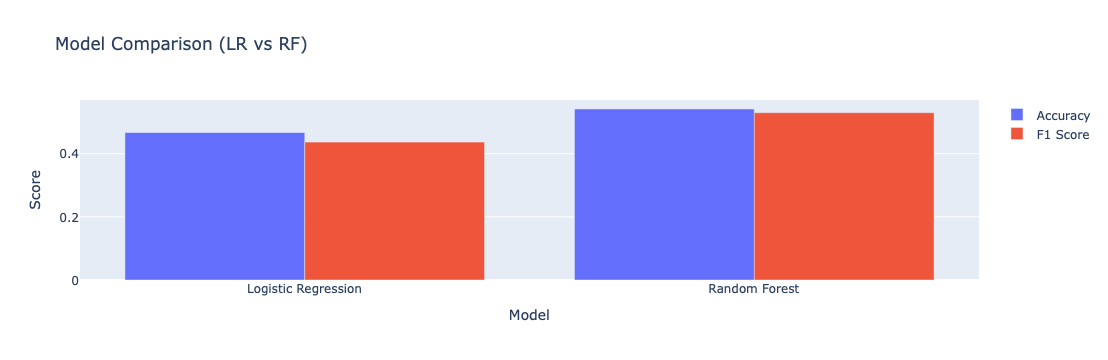

In [51]:
import plotly.graph_objects as go
models = ["Logistic Regression", "Random Forest"]
accuracy = [acc_lr, test_acc_rf]
f1_scores = [f1_lr, test_f1_rf]
fig = go.Figure()
fig.add_trace(go.Bar(name='Accuracy', x=models, y=accuracy))
fig.add_trace(go.Bar(name='F1 Score', x=models, y=f1_scores))
fig.update_layout(
    title="Model Comparison (LR vs RF)",
    xaxis_title="Model",
    yaxis_title="Score",
    barmode='group'
)
fig.show()

Random Forest significantly outperforms Logistic Regression, indicating that non-linear relationships between words contribute meaningfully to emoji prediction.

While Random Forest achieves higher accuracy and F1-score than Logistic Regression by capturing non-linear feature interactions, the moderate performance levels indicate that emoji prediction remains fundamentally constrained by semantic ambiguity and overlapping contextual meanings.